In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as mticker
from linearmodels.iv import IV2SLS
import glob

In [2]:
## import HCRIS and medicaid expansion + merge

# state crosswalk
crosswalk = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# load and clean mediciad
kff = pd.read_csv('../HW5/data/medicaid-expansion-data.csv', encoding='utf-8-sig')
kff['ballot_initiative'] = kff['ballot_initiative'].str.strip()
kff['implementation_date'] = pd.to_datetime(kff['implementation_date'], errors='coerce')
kff['state'] = kff['Location'].map(crosswalk)

# HCRIS data
hcris_files = glob.glob('../HW5/data/output/data-*.csv')
hcris = pd.concat([pd.read_csv(f, encoding='utf-8-sig') for f in hcris_files], ignore_index=True)

hcris['state'] = hcris['state'].str.strip()

full_name_fix = {
    'ILLINOIS': 'IL', 'ARIZONA': 'AZ', 'CALIFORNIA': 'CA',
    'NORTH CAROLINA': 'NC', 'WISCONSIN': 'WI', 'MONTANA': 'MT',
    'MICHIGAN': 'MI', 'TENNESSEE': 'TN', 'UTAH': 'UT',
    'Illinois': 'IL', 'Arizona': 'AZ', 'California': 'CA',
    'North Carolina': 'NC', 'Wisconsin': 'WI', 'Montana': 'MT',
    'Michigan': 'MI', 'Tennessee': 'TN', 'Utah': 'UT',
}
hcris['state'] = hcris['state'].replace(full_name_fix)

# Fix typos
hcris['state'] = hcris['state'].replace({'AX': 'AZ', 'KA': 'KS'})

# Fix TE split by city
tennessee_cities = ['TULLAHOMA', 'MANCHESTER', 'MEMPHIS', 'NASHVILLE', 'KNOXVILLE', 'CHATTANOOGA']
hcris.loc[(hcris['state'] == 'TE') & (hcris['city'].str.upper().isin(tennessee_cities)), 'state'] = 'TN'
hcris.loc[hcris['state'] == 'TE', 'state'] = 'TX'

# Drop territories and nulls
territories = ['PR', 'VI', 'GU', 'MP', 'AS', 'P.']
hcris_clean = hcris[~hcris['state'].isin(territories)].copy()
hcris_clean = hcris_clean[hcris_clean['state'].notna()]

valid_abbrevs = set(crosswalk.values())
still_bad = hcris_clean[~hcris_clean['state'].isin(valid_abbrevs)]['state'].unique()
print("Still invalid after cleaning:", still_bad)

# Merge
merged = hcris_clean.merge(kff, on='state', how='left')
unmatched = merged[merged['expansion_status'].isna()]['state'].unique()
print("Unmatched after merge:", unmatched)
print("Merged shape:", merged.shape)


Still invalid after cleaning: []
Unmatched after merge: []
Merged shape: (159155, 31)


In [13]:
#Question 1
# Create uncompensated care variable
merged['uncomp_care'] = (merged['tot_charges'] - merged['tot_discounts'])/1000000

# Filter 2010-2018 and compute
uncomp_table = (
    merged[merged['year'].between(2010, 2018)]
    .groupby('year')['uncomp_care']
    .mean()
    .reset_index()
    .rename(columns={'uncomp_care': 'mean_uncomp_care_millions'})
)
uncomp_table['mean_uncomp_care_millions'] = uncomp_table['mean_uncomp_care_millions'].round(2)

print(uncomp_table.to_string(index=False))



 year  mean_uncomp_care_millions
 2010                     126.21
 2011                     131.56
 2012                     134.69
 2013                     138.37
 2014                     145.42
 2015                     152.15
 2016                     159.80
 2017                     166.46
 2018                     176.20


In [ ]:
#over time uncompensated care has increased

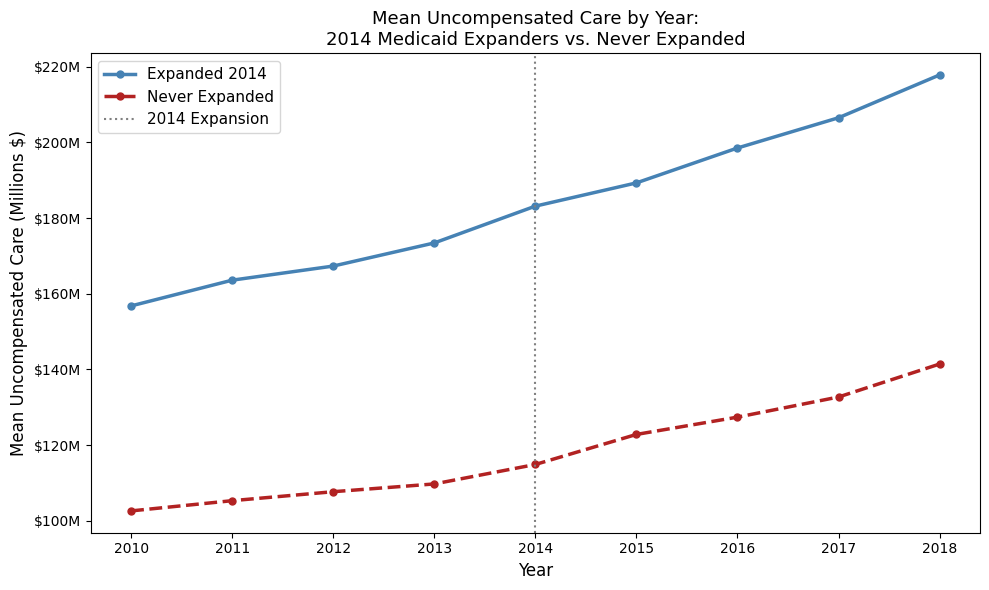

In [14]:
#Question 2

# implementation dates
merged['implementation_date'] = pd.to_datetime(merged['implementation_date'], errors='coerce')
merged['expand_year'] = merged['implementation_date'].dt.year

# Classify states
# Drop states that expanded after 2014
merged_q2 = merged[
    (merged['expand_year'] == 2014) | (merged['expansion_status'] == 'Not Adopted')
].copy()

merged_q2['group'] = merged_q2['expand_year'].apply(
    lambda x: 'Expanded 2014' if x == 2014 else 'Never Expanded'
)

# Filter years 2010-2018
merged_q2 = merged_q2[merged_q2['year'].between(2010, 2018)]

# Mean uncompensated care by year and group
plot_data = (
    merged_q2.groupby(['year', 'group'])['uncomp_care']
    .mean()
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for group, color, ls in [('Expanded 2014', 'steelblue', '-'), 
                           ('Never Expanded', 'firebrick', '--')]:
    d = plot_data[plot_data['group'] == group]
    ax.plot(d['year'], d['uncomp_care'], label=group, color=color, 
            linestyle=ls, linewidth=2.5, marker='o', markersize=5)

# Add vertical line at 2014
ax.axvline(x=2014, color='gray', linestyle=':', linewidth=1.5, label='2014 Expansion')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Uncompensated Care (Millions $)', fontsize=12)
ax.set_title('Mean Uncompensated Care by Year:\n2014 Medicaid Expanders vs. Never Expanded', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout()
plt.savefig('uncomp_care_parallel_trends.png', dpi=150)
plt.show()


In [ ]:
#This graph does not suggest a treatment effect as uncompensated care seems to continue rising post 2014 even in expansion states

In [15]:
#Question 3

# Filter to 2012 and 2015 only, 2014 expanders and never-expanded
dd_data = merged_q2[merged_q2['year'].isin([2012, 2015])].copy()
dd_data['post'] = (dd_data['year'] == 2015).astype(int)
dd_data['treated'] = (dd_data['group'] == 'Expanded 2014').astype(int)

# 2x2 means
dd_table = (
    dd_data.groupby(['group', 'year'])['uncomp_care']
    .mean()
    .round(2)
    .unstack('year')
    .rename(columns={2012: 'Pre (2012)', 2015: 'Post (2015)'})
)

# Add difference column
dd_table['Difference'] = (dd_table['Post (2015)'] - dd_table['Pre (2012)']).round(2)

# Add DD row
dd_row = dd_table.loc['Expanded 2014'] - dd_table.loc['Never Expanded']
dd_table.loc['DD (Expanded - Never)'] = dd_row

print(dd_table.to_string())

year                   Pre (2012)  Post (2015)  Difference
group                                                     
Expanded 2014              167.31       189.30       21.99
Never Expanded             107.67       122.81       15.14
DD (Expanded - Never)       59.64        66.49        6.85


In [ ]:
#Question 4
#Caveat: I think my code is wrong because this is suggesting that expanded states actually saw greater increases in uncompensated care
# Increases in the insured population in insured states, especially amongst vunerable, poorer populations, directly affects the groups which are most likely to drive uncompensated care. Insuring these populations drops rates of uncompensated care as now the hospitals are paid by medicaid.

In [ ]:
#Question 5